## Table of Contents:
* [1. Within-Replicates ](#first-bullet)
* [2. Across conditions](#second-bullet)
* [3. Baseline](#third-bullet)

In [1]:
import pybedtools, os, re, pickle, math
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import matplotlib.gridspec as gridspec

In [2]:
sns.set(style='whitegrid', rc={"figure.dpi":100, 'savefig.dpi':300})  
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = ['Arial', 'sans-serif']

In [7]:
df_within = pd.read_csv('01_inputfiles/tobias_within_replicate.csv.gz', sep=",") 
df_across = pd.read_csv('01_inputfiles/tobias_across_replicate.csv.gz', sep=",") 
ref_df = pd.read_csv('01_inputfiles/tobias_across_cellline.csv.gz', sep=",") 
display(df_within)

,name,comparison,change,pvalue,condition,-log10(pvalue),cellline,sampling_type
0,ALX3_MA0634.1,rep1_rep3,-0.00787,5.256040e-23,c1000,22.279341,MCF7,c
1,ARNT2_MA1464.1,rep1_rep2,0.00596,1.276760e-12,c1000,11.893891,K562,c
2,ARGFX_MA1463.1,rep2_rep3,-0.00375,3.511330e-10,c1000,9.454528,K562,c
3,ARGFX_MA1463.1,rep1_rep3,-0.00586,2.940590e-12,c1000,11.531566,K562,c
4,ARGFX_MA1463.1,rep1_rep2,-0.00212,2.012650e-05,c1000,4.696232,K562,c
...,...,...,...,...,...,...,...,...
158944,ARGFX_MA1463.1,rep1_rep3,-0.00749,3.731170e-18,r5e8,17.428155,HEPG2,r
158945,ARGFX_MA1463.1,rep2_rep3,-0.00964,7.666180e-25,r5e8,24.115421,HEPG2,r
158946,ARNT2_MA1464.1,rep1_rep2,0.00415,8.332690e-10,r5e8,9.079215,HEPG2,r
158947,mix-a_MA0621.1,rep1_rep2,-0.00671,8.625870e-20,r5e8,19.064197,K562,r


# 1. Within Replicates <a class="anchor" id="first-bullet"></a>

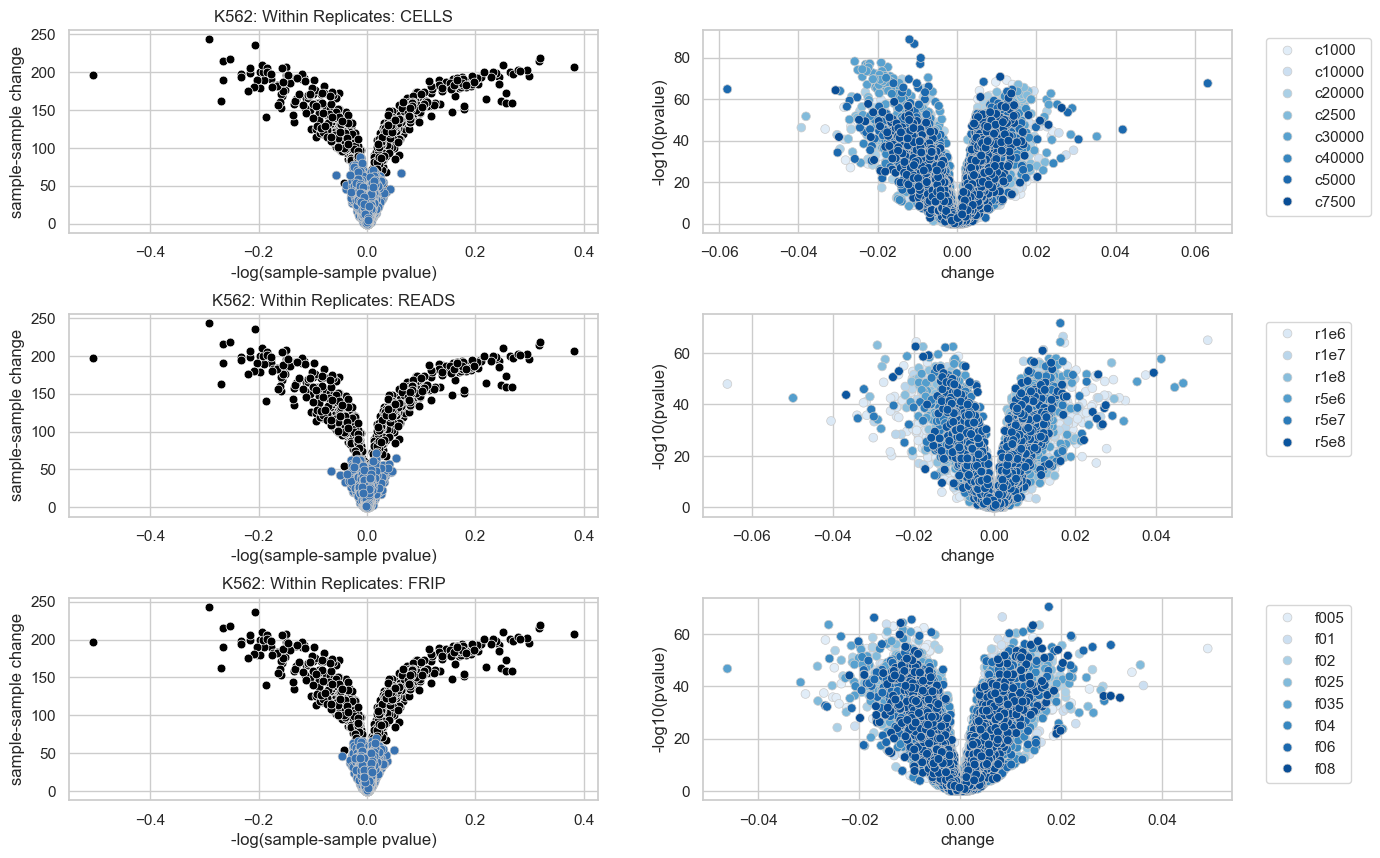

In [8]:
##SAME CELL LINE ACROSS SAMPLING TYPES

def custom_plot(ax0, ax1, df, cl, st, ref_df):
    df1 = df[(df.cellline == cl) & (df.sampling_type==st)]
    
    myx = 'change'
    myy = "-log10(pvalue)"
    
    sns.scatterplot(x=ref_df[myx], y=ref_df[myy], color="black", s=40, ax=ax0)
    sns.scatterplot(data=df1, x=myx, y=myy,  color='#3872B1', edgecolor="#CCCCCC", s=40, ax=ax0)
    ax0.set_ylabel("sample-sample change")
    ax0.set_xlabel("-log(sample-sample pvalue)")

    sns.scatterplot(data=df1, x=myx, y=myy, hue='condition', palette="Blues", edgecolor="#CCCCCC", s=40, ax=ax1)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    return ax0, ax1


fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.4)#, width_ratios=[1,2])

cl = "K562"
ax0 = fig.add_subplot(gs[0])  
ax1 = fig.add_subplot(gs[1])  
custom_plot(ax0, ax1, df_within, cl, "c", ref_df)
ax0.set_title(f"{cl}: Within Replicates: CELLS")

ax0 = fig.add_subplot(gs[2])  
ax1 = fig.add_subplot(gs[3])  
custom_plot(ax0, ax1, df_within, cl, "r", ref_df)
ax0.set_title(f"{cl}: Within Replicates: READS")

ax0 = fig.add_subplot(gs[4])  
ax1 = fig.add_subplot(gs[5])  
custom_plot(ax0, ax1, df_within, cl, "f", ref_df)
ax0.set_title(f"{cl}: Within Replicates: FRIP")

plt.show()

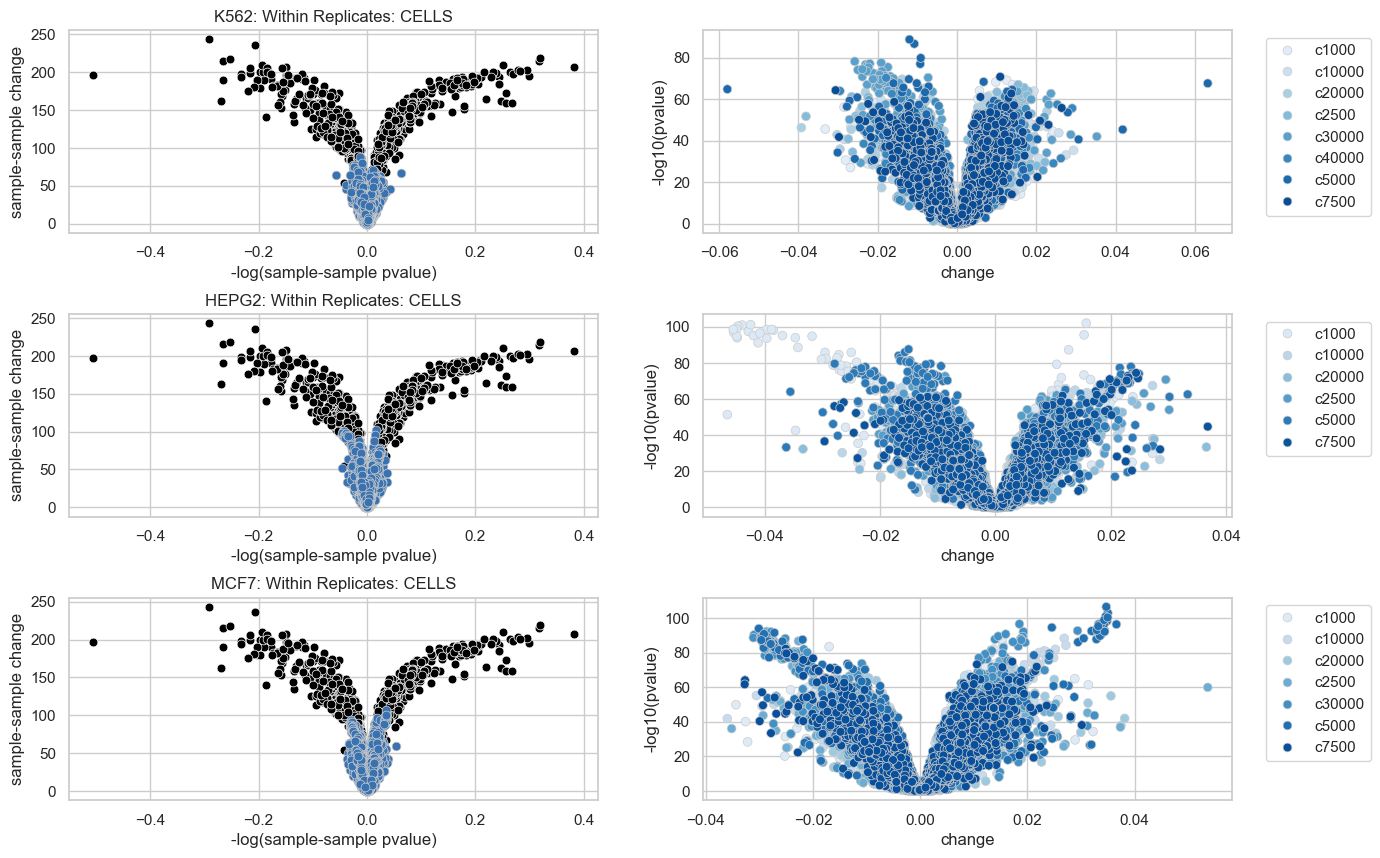

In [9]:
##DIFF CELLTYPES ACROSS SAME SAMPLING TYPE. 

fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.4)#, width_ratios=[1,2])

ax0 = fig.add_subplot(gs[0])  
ax1 = fig.add_subplot(gs[1])  
custom_plot(ax0, ax1, df_within, "K562", "c", ref_df)
ax0.set_title(f"K562: Within Replicates: CELLS")

ax0 = fig.add_subplot(gs[2])  
ax1 = fig.add_subplot(gs[3])  
custom_plot(ax0, ax1, df_within, "HEPG2", "c", ref_df)
ax0.set_title(f"HEPG2: Within Replicates: CELLS")

ax0 = fig.add_subplot(gs[4])  
ax1 = fig.add_subplot(gs[5])  
custom_plot(ax0, ax1, df_within, "MCF7", "c", ref_df)
ax0.set_title(f"MCF7: Within Replicates: CELLS")

plt.show()

# 2. Across Conditions <a class="anchor" id="second-bullet"></a>

In [10]:
#do some cleaning and make sure fold changes are in the right direction 
df_across[["cond1", "cond2"]] = df_across['condition'].str.split('_', n=1, expand=True)
df_across["cond1"] = df_across["cond1"].str[1:].astype(float)
df_across["cond2"] = df_across["cond2"].str[1:].astype(float)

mask = df_across['cond2'] > df_across['cond1']
df_across.loc[mask, "change"] = df_across.loc[mask, "change"] * -1
display(df_across)

,name,comparison,change,pvalue,condition,-log10(pvalue),cellline,sampling_type,cond1,cond2
0,Isl1_MA1608.1,c1000_c40000,0.03778,1.923640e-79,c1000_c40000,78.715876,K562,c,1000.0,40000.0
1,Isl1_MA1608.1,c1000_c30000,0.04745,3.961120e-89,c1000_c30000,88.402182,K562,c,1000.0,30000.0
2,ZBTB7B_MA0694.1,c2500_c7500,0.01971,6.194370e-50,c2500_c7500,49.208003,MCF7,c,2500.0,7500.0
3,Isl1_MA1608.1,c1000_c5000,0.04852,2.268600e-95,c1000_c5000,94.644242,K562,c,1000.0,5000.0
4,Isl1_MA1608.1,c1000_c7500,0.05688,3.961860e-99,c1000_c7500,98.402101,K562,c,1000.0,7500.0
...,...,...,...,...,...,...,...,...,...,...
237998,OTX2_MA0712.2,r1e8_r5e7,0.02331,5.007060e-83,r1e8_r5e7,82.300417,K562,r,100000000.0,50000000.0
237999,OTX2_MA0712.2,r1e8_r5e8,-0.00757,2.448660e-40,r1e8_r5e8,39.611072,K562,r,100000000.0,500000000.0
238000,OTX2_MA0712.2,r5e6_r5e7,0.04833,1.734160e-112,r5e6_r5e7,111.760911,K562,r,5000000.0,50000000.0
238001,OTX2_MA0712.2,r5e7_r5e8,0.01248,4.843430e-56,r5e7_r5e8,55.314847,K562,r,50000000.0,500000000.0


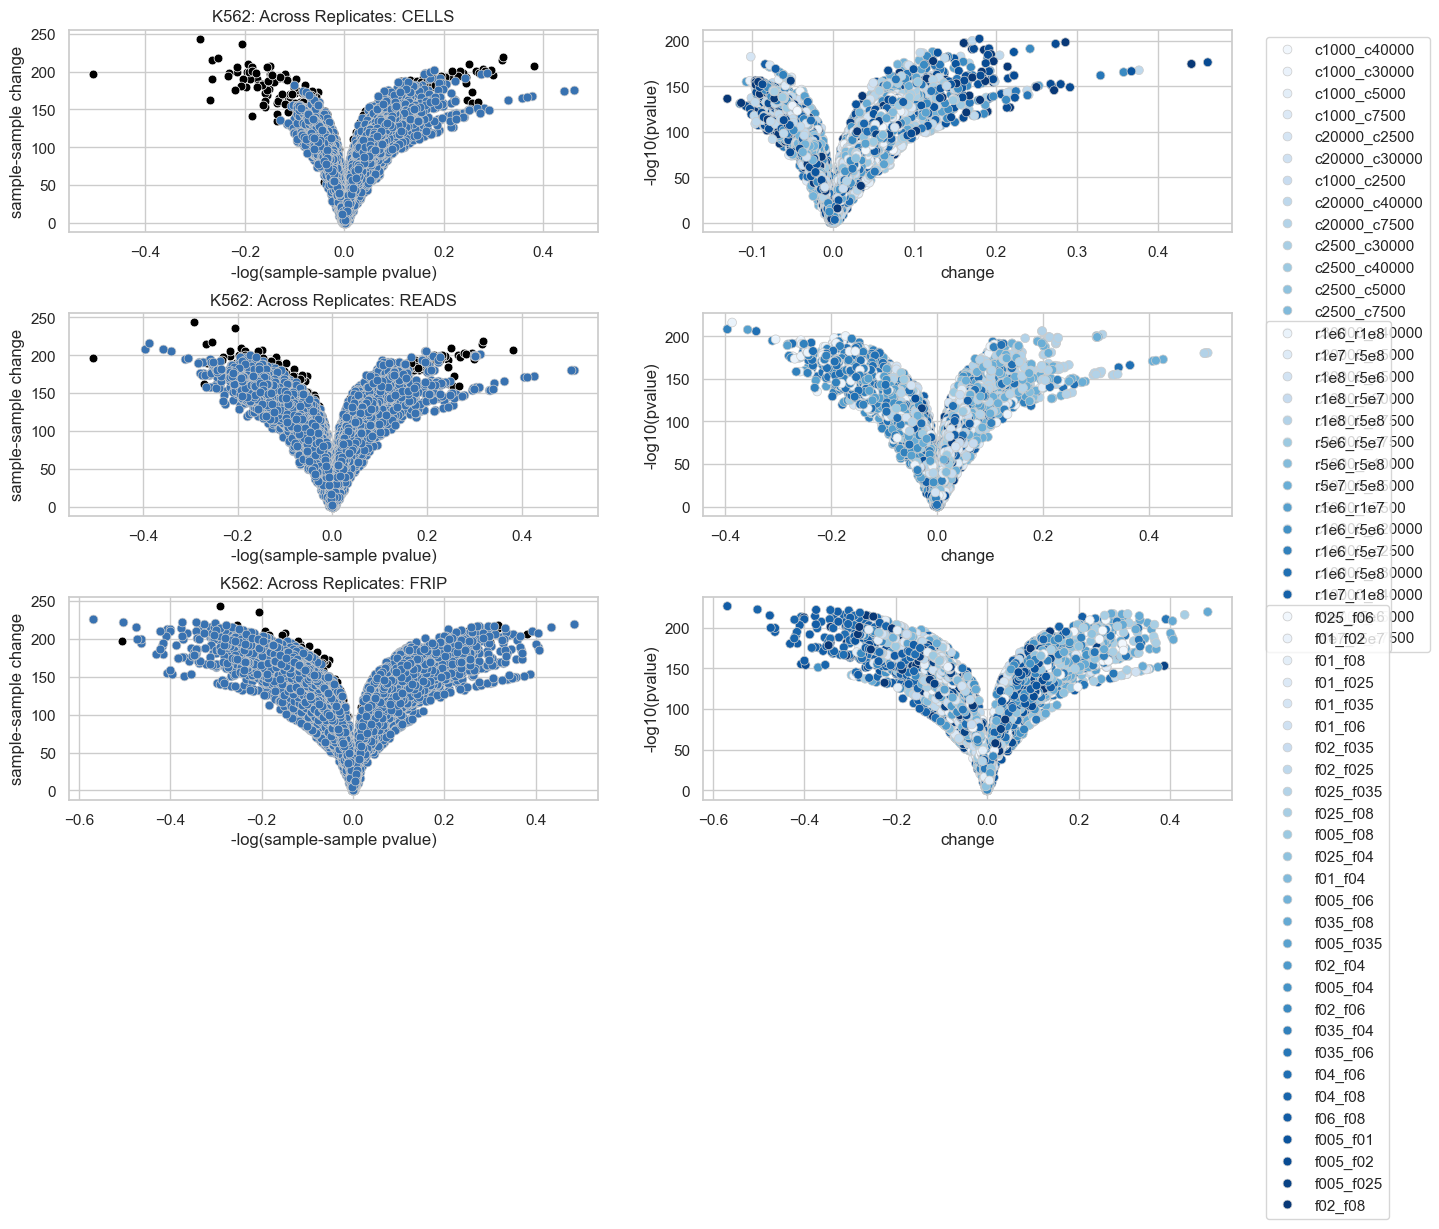

In [11]:
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.4)#, width_ratios=[1,2])

cl = "K562"
ax0 = fig.add_subplot(gs[0])  
ax1 = fig.add_subplot(gs[1])  
custom_plot(ax0, ax1, df_across, cl, "c", ref_df)
ax0.set_title(f"{cl}: Across Replicates: CELLS")

ax0 = fig.add_subplot(gs[2])  
ax1 = fig.add_subplot(gs[3])  
custom_plot(ax0, ax1, df_across, cl, "r", ref_df)
ax0.set_title(f"{cl}: Across Replicates: READS")

ax0 = fig.add_subplot(gs[4])  
ax1 = fig.add_subplot(gs[5])  
custom_plot(ax0, ax1, df_across, cl, "f", ref_df)
ax0.set_title(f"{cl}: Across Replicates: FRIP")

plt.show()


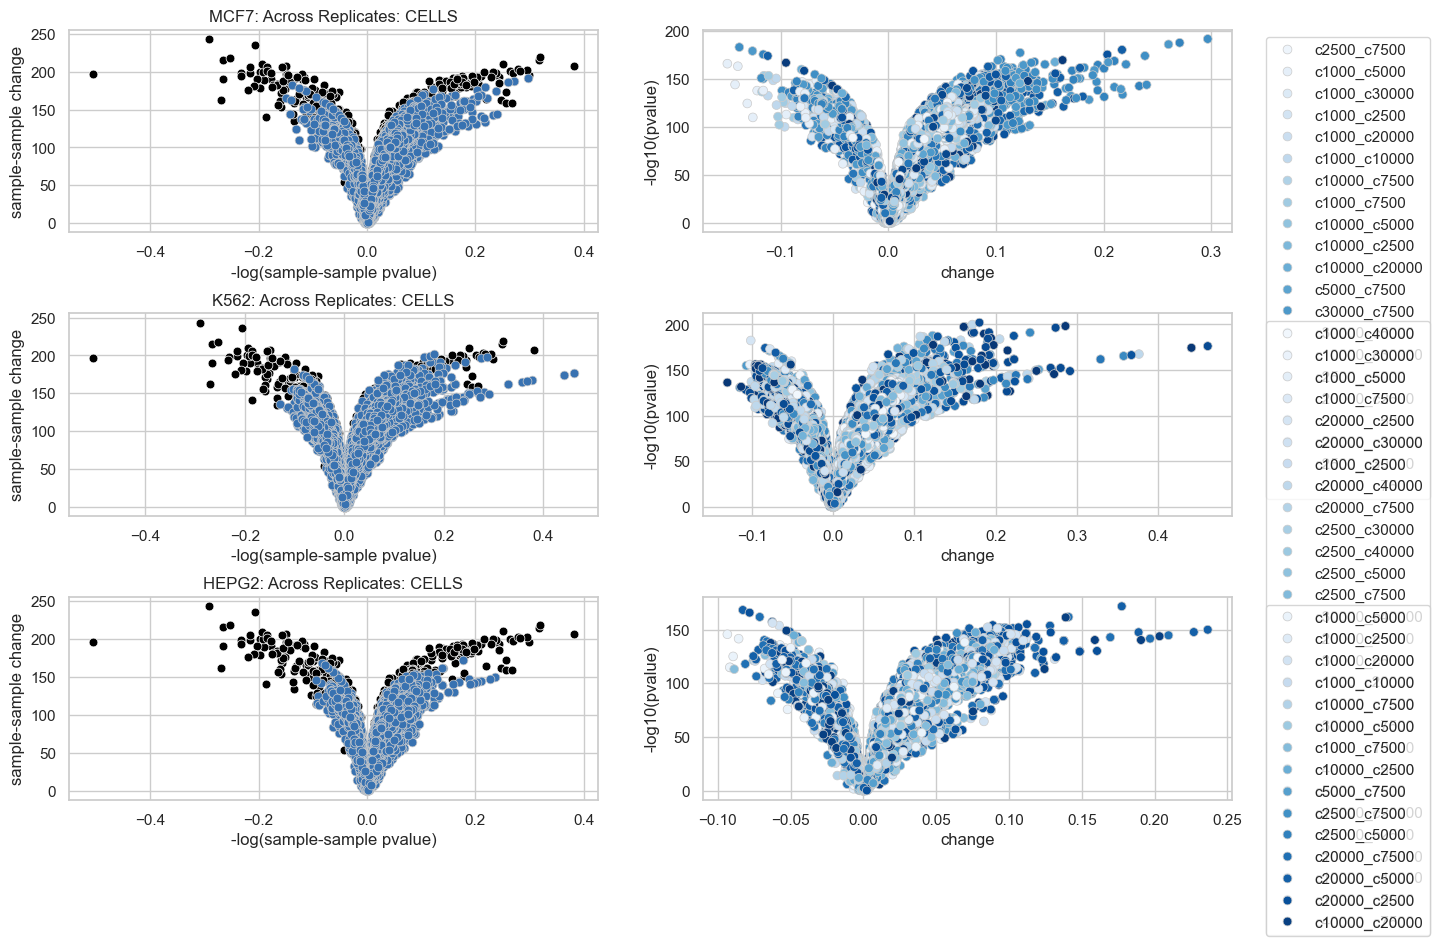

In [12]:
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 2, figure=fig, hspace=0.4)#, width_ratios=[1,2])

ax0 = fig.add_subplot(gs[0])  
ax1 = fig.add_subplot(gs[1])  
custom_plot(ax0, ax1, df_across, "MCF7", "c", ref_df)
ax0.set_title(f"MCF7: Across Replicates: CELLS")

ax0 = fig.add_subplot(gs[2])  
ax1 = fig.add_subplot(gs[3])  
custom_plot(ax0, ax1, df_across, "K562", "c", ref_df)
ax0.set_title(f"K562: Across Replicates: CELLS")

ax0 = fig.add_subplot(gs[4])  
ax1 = fig.add_subplot(gs[5])  
custom_plot(ax0, ax1, df_across, "HEPG2", "c", ref_df)
ax0.set_title(f"HEPG2: Across Replicates: CELLS")

plt.show()


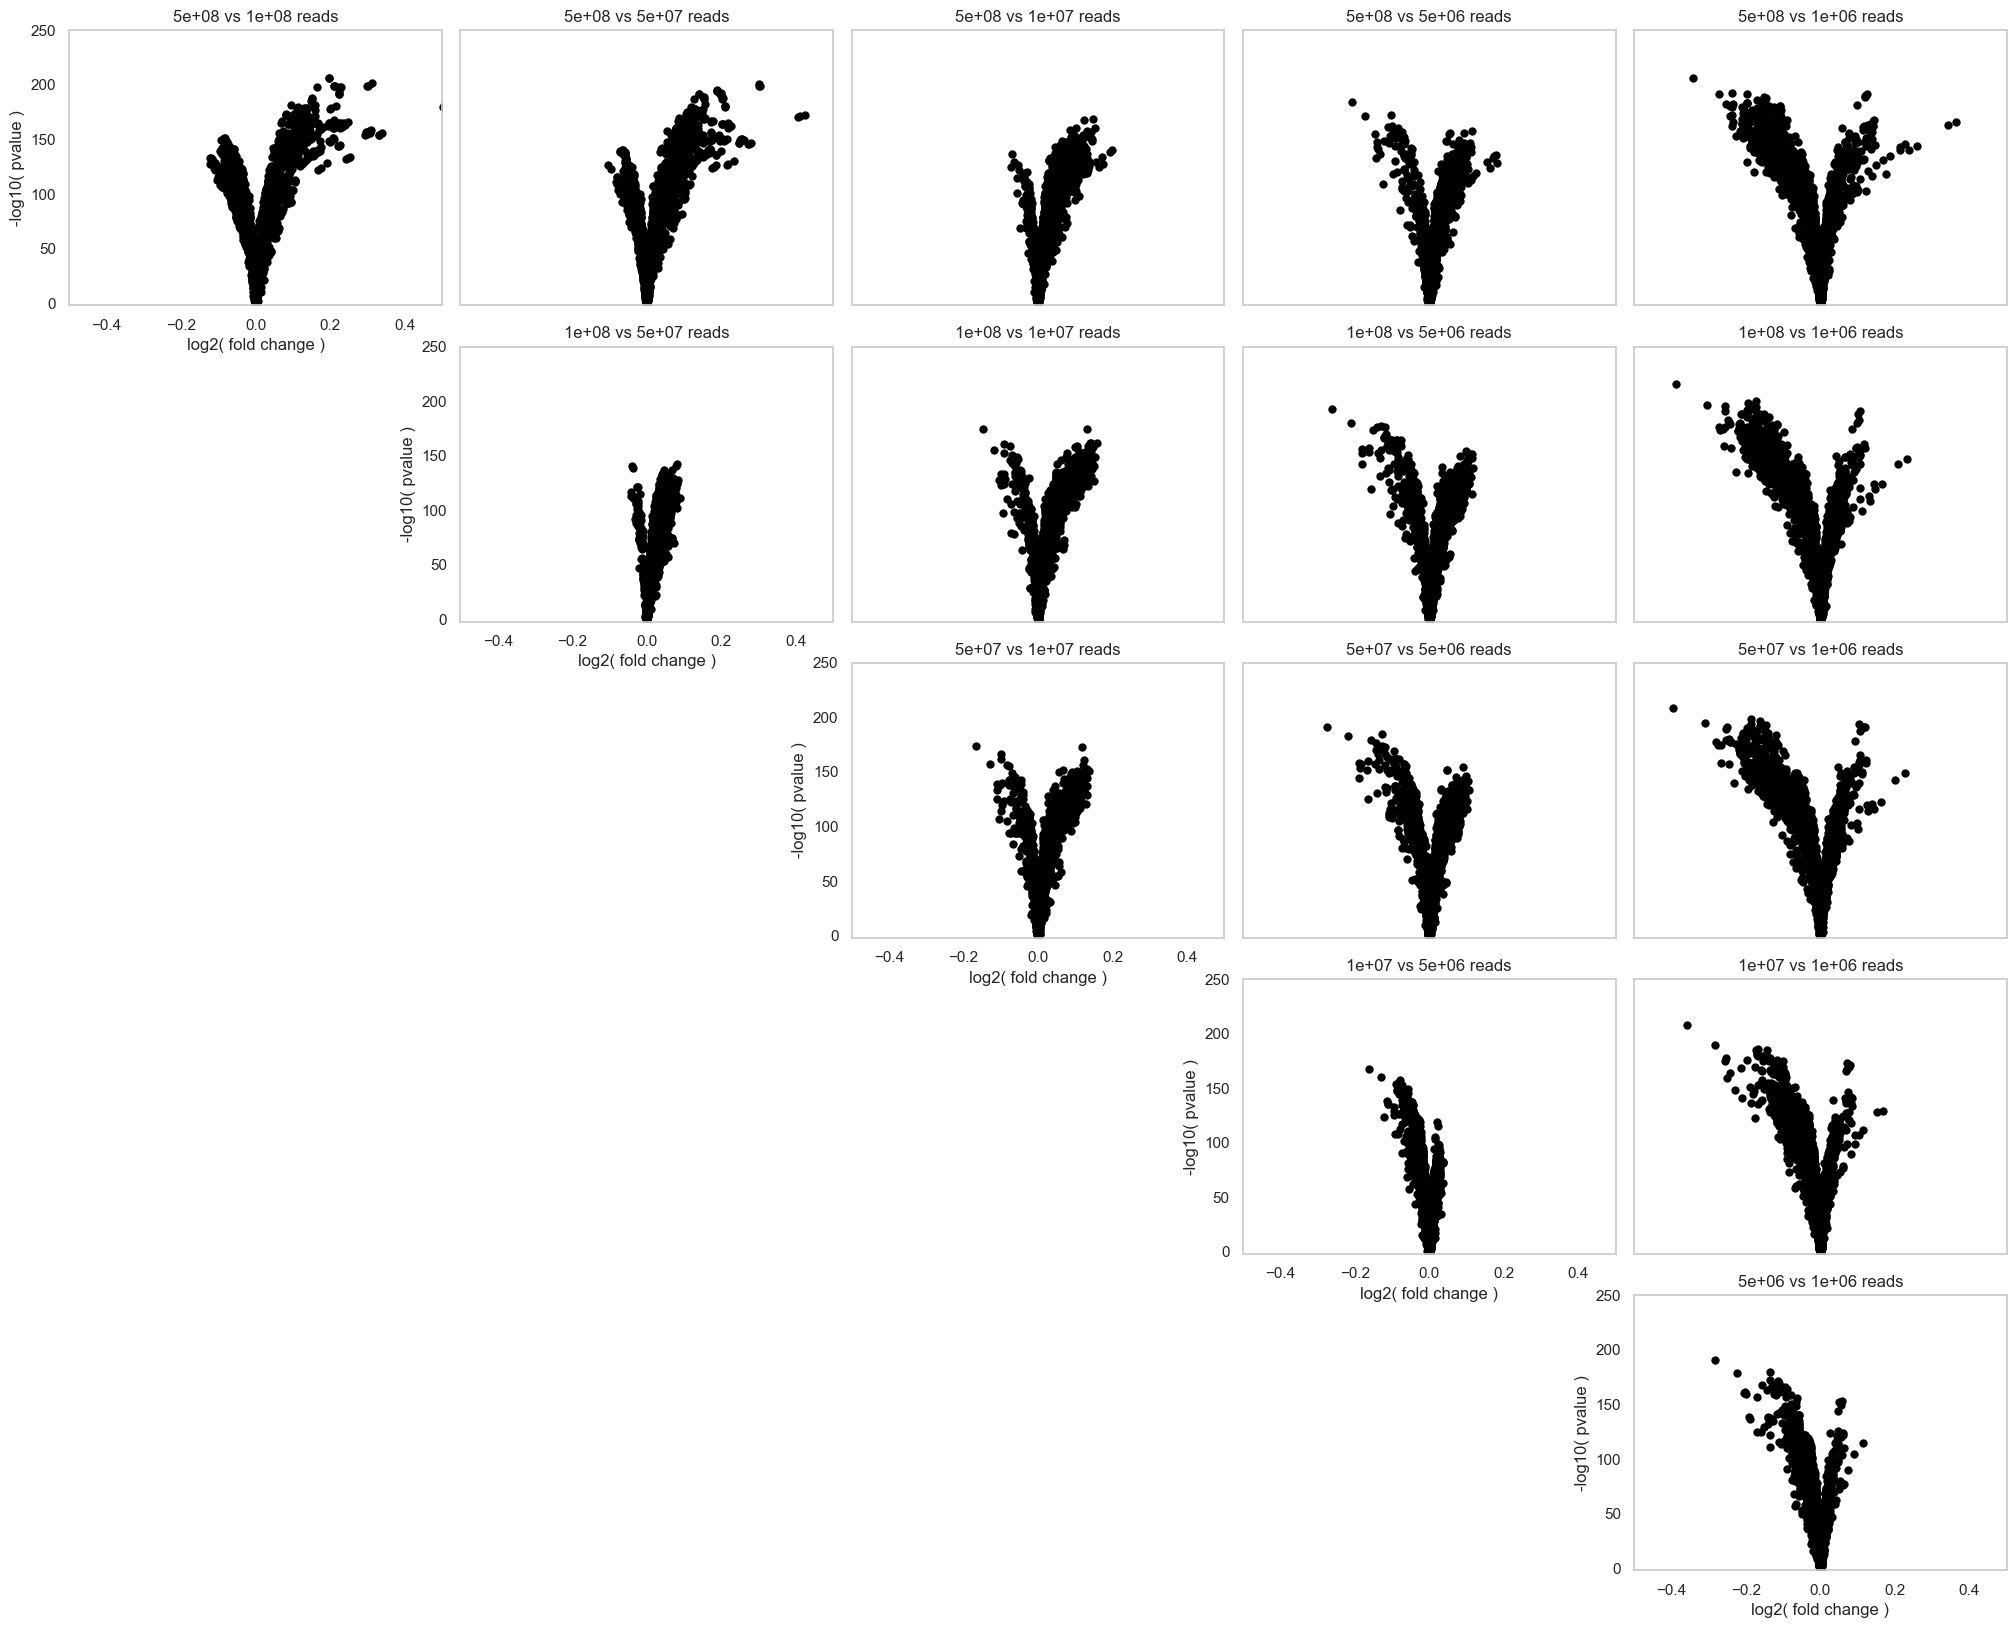

In [13]:
fig, axs = plt.subplots(nrows=5, ncols=5, figsize=(25, 20))
plt.subplots_adjust(hspace=0.15, wspace=0.05)


df1 = df_across[(df_across.cellline == "K562") & (df_across.sampling_type == "r")]
myx = 'change'
myy = "-log10(pvalue)"

l = ['r1e8_r5e8', 'r5e7_r5e8', 'r1e7_r5e8', 'r5e6_r5e8', 'r1e6_r5e8',
     "blank",  'r1e8_r5e7', 'r1e7_r1e8', 'r1e8_r5e6', 'r1e6_r1e8',
     "blank", "blank", 'r1e7_r5e7', 'r5e6_r5e7', 'r1e6_r5e7',
     "blank","blank","blank", 'r1e7_r5e6','r1e6_r1e7',
     "blank","blank","blank","blank", 'r1e6_r5e6']


for idx, (ticker, ax) in enumerate(zip(l, axs.ravel())):
    if ticker == "blank":
        ax.axis('off')  # Turn off the axis for empty positions
    else: 
        sns.scatterplot(data = df1[df1.comparison == ticker], x=myx, y=myy, color="black", ax=ax, linewidth=0,
                       rasterized=True) 
        
        ax.set_xlim(-0.5, 0.5)
        ax.set_ylim(-2, 250)
        if ticker != "blank":
            vals = [float(re.sub("r", "", i)) for i in ticker.split('_')]
            svals = (np.sort(vals))[::-1]
            title = f"{svals[0]:.0e} vs {svals[1]:.0e} reads"
            ax.set_title(title)
    
        ax.set_ylabel("-log10( pvalue )")
        ax.set_xlabel("log2( fold change )")
        ax.grid(False)
        if idx not in [0, 6, 12, 18, 24]:
            ax.set_ylabel("")
            ax.set_yticklabels([])
            #ax.set_yticks([])
            
            ax.set_xlabel("")
            ax.set_xticklabels([])
            #ax.set_xticks([])

plt.show()

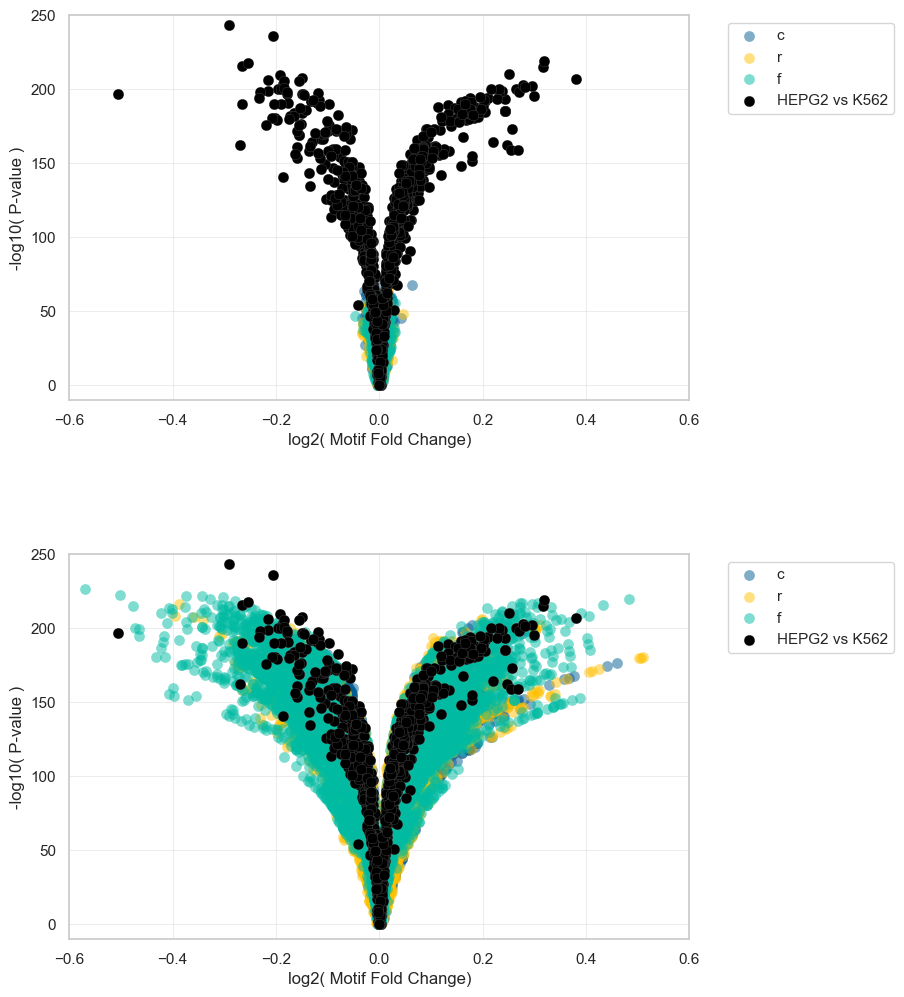

In [15]:
#color_scheme_st = {"c":"#CE3B59", "f":"#F5C23C", "r":"#993CBE"}
color_scheme_st = {"c":"#005D93", "f":"#00BBA2", "r":"#ffc000", "b":"black"}
fig = plt.figure(figsize=(8, 12))
gs = GridSpec(2, 1, figure=fig, hspace=0.4)

cl = "K562"
myx = 'change'
myy = "-log10(pvalue)"

ax0 = fig.add_subplot(gs[0])  
ax1 = fig.add_subplot(gs[1]) 

for st in ["c", "r", "f"]:
    sns.scatterplot(data=df_within[(df_within.cellline == cl) & (df_within.sampling_type==st) & (df_within.comparison=="rep1_rep2")], 
                    x=myx, y=myy, 
                    color=color_scheme_st[st], 
                    alpha=0.5,
                    linewidth=0,
                    rasterized=True,
                    s=60, ax=ax0,
                    label=st)

    sns.scatterplot(data=df_across[(df_across.cellline == cl) & (df_across.sampling_type==st)], 
                    x=myx, y=myy, 
                    color=color_scheme_st[st], 
                    alpha=0.5,
                    linewidth=0,
                    rasterized=True,
                    s=60, ax=ax1,
                    label=st)


sns.scatterplot(data=ref_df, x=myx, y=myy,  
                color="black", 
                edgecolor="#CCCCCC", 
                linewidth=0.1,
                s=60, ax=ax0, 
                label="HEPG2 vs K562")
sns.scatterplot(data=ref_df, x=myx, y=myy,  
                color="black", 
                edgecolor="#CCCCCC", 
                linewidth=0.1,
                s=60, ax=ax1, 
                label="HEPG2 vs K562")


ax0.set_ylim(-10, 250)
ax1.set_ylim(-10, 250)
ax0.set_xlim(-0.6, 0.6)
ax1.set_xlim(-0.6, 0.6)

ax0.set_xlabel("log2( Motif Fold Change)")
ax0.set_ylabel("-log10( P-value )")
ax1.set_xlabel("log2( Motif Fold Change)")
ax1.set_ylabel("-log10( P-value )")

ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax0.grid(which='major', color='#DDDDDD', linewidth=0.4)
ax1.grid(which='major', color='#DDDDDD', linewidth=0.4)

plt.show()

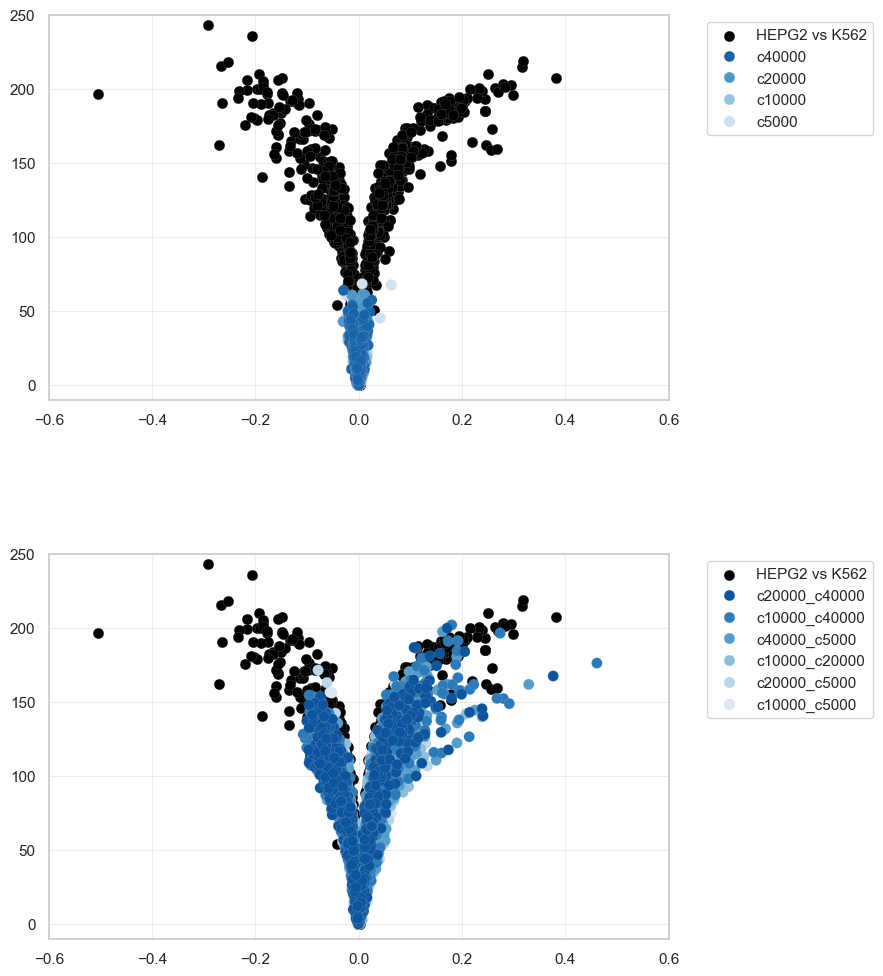

In [16]:
color_scheme_st = {"c":"#CE3B59", "f":"#F5C23C", "r":"#993CBE"}

fig = plt.figure(figsize=(8, 12))
gs = GridSpec(2, 1, figure=fig, hspace=0.4)

cl = "K562"
myx = 'change'
myy = "-log10(pvalue)"

ax0 = fig.add_subplot(gs[0])  
ax1 = fig.add_subplot(gs[1]) 

sns.scatterplot(data=ref_df, x=myx, y=myy,  
                color="black", 
                edgecolor="#CCCCCC", linewidth=0.1, 
                #linewidth=0, rasterized=True,
                s=60, ax=ax0, 
                label="HEPG2 vs K562")
sns.scatterplot(data=ref_df, x=myx, y=myy,  
                color="black", 
                edgecolor="#CCCCCC", linewidth=0.1, 
                #linewidth=0, rasterized=True,
                s=60, ax=ax1, 
                label="HEPG2 vs K562")


selected = ["c40000", "c20000", "c10000", "c5000"]
cond1 = (df_within.cellline == cl)
cond2 = (df_within.sampling_type=="c")
cond3 = (df_within.comparison=="rep1_rep2")
cond4 = (df_within.condition.isin(selected))
tmp = df_within[cond1 & cond2 & cond3 & cond4].copy()
tmp["condition"] = pd.Categorical(tmp["condition"], categories=selected, ordered=True)
tmp = tmp.sort_values("condition", ascending=False)

sns.scatterplot(data=tmp, x=myx, y=myy,  
                hue='condition',
                palette = "Blues_r",
                hue_order = selected,
                linewidth=0.1, edgecolor="#CCCCCC", 
                #linewidth=0, 
                rasterized=True,
                s=60, ax=ax0)

selected = ['c20000_c40000', 'c10000_c40000', 'c40000_c5000', 'c10000_c20000', 'c20000_c5000','c10000_c5000']
cond1 = (df_across.cellline == cl)
cond2 = (df_across.sampling_type=="c")
cond4 = (df_across.condition.isin(selected))
tmp = df_across[cond1 & cond2 & cond4].copy()
tmp["condition"] = pd.Categorical(tmp["condition"], categories=selected, ordered=True)
tmp = tmp.sort_values("condition", ascending=False)
sns.scatterplot(data=tmp, x=myx, y=myy,  
                hue='condition',
                palette = "Blues_r",
                hue_order = selected,
                linewidth=0.1, edgecolor="#CCCCCC", 
                #linewidth=0, 
                rasterized=True,
                s=60, ax=ax1)


ax0.set_ylim(-10, 250)
ax1.set_ylim(-10, 250)
ax0.set_xlim(-0.6, 0.6)
ax1.set_xlim(-0.6, 0.6)

ax0.set_ylabel(""); ax0.set_xlabel("")
ax1.set_ylabel(""); ax1.set_xlabel("")

ax0.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax0.grid(which='major', color='#DDDDDD', linewidth=0.4)
ax1.grid(which='major', color='#DDDDDD', linewidth=0.4)

plt.show()